# Overview

**What's inside:**  
This is an example of using Model Ensembles to combine multiple models so we can even out their weaknesses to get a better score.  
I tried: **GradientBoostRegressor, XBoostRegressor, CatBoostRegressor, Lasso KernelRidge**.  
I settled on **GradientBoostRegressor, CatBoostRegressor, KernelRidge**, these get **stacked using the SGDRegressor**. 

# Load Training Data

In [1]:
# Core Data and Math Libraries
import numpy as np # Added for general math operations (common best practice)
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Scikit-learn: Model Selection and Validation
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

# Scikit-learn: Preprocessing and Utility
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer # Included here for completeness, though often custom in advanced projects

# Scikit-learn: Models (Ensembles and Linear)
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Lasso, Ridge
import xgboost as xgb # Imported separately as a third-party package


# Load the data, and separate the target
train_file_path = '/kaggle/input/competitions/home-data-for-ml-course/train.csv'
home_data = pd.read_csv(train_file_path)

# Understanding the data


 Understanding the data is the most important step as it directly determines how effective the learning algorithms are.
 
 I've looked at:
 * what the data distribution is for each column ( informs: missing values, one hot encoding, categorical ordering, scaling)
 * the relationships between key columns (to inform necessary feature engineering)

 Since real data is messy one critical step is Outlier Removal.
 The models will fit better the data if there are few outliers.

## Display Outliers

In [2]:
import seaborn as sns
import numpy as np

def outlier_detection_vs_price(df):
    salePriceCol = 'SalePrice'

    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    if salePriceCol in numerical_cols:
        numerical_cols.remove(salePriceCol)
    
    no_cols = len(numerical_cols)
    ncols = 2
    nrows = int(np.ceil(no_cols / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 8 * nrows))
    axes = axes.flatten()

    for idx, col in enumerate(numerical_cols):
        # 2. Visualize the relationship
        sns.scatterplot(x=col, y='SalePrice', data=df, ax=axes[idx])
        axes[idx].set_title(f"Scatter: {col} vs. {salePriceCol} ")
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(salePriceCol)
        axes[idx].grid(True)

    # 5. Adjust layout to prevent titles/labels from overlapping
    plt.tight_layout()

    # 6. Display the combined figure
    plt.show()

#outlier_detection_vs_price(home_data)

## Show data distributions aka skewed

I wont place the code here since it dilutes, but I checked the data distribition to see which columns were right-skewed as these would benefit from log transformation

## Show correlated features

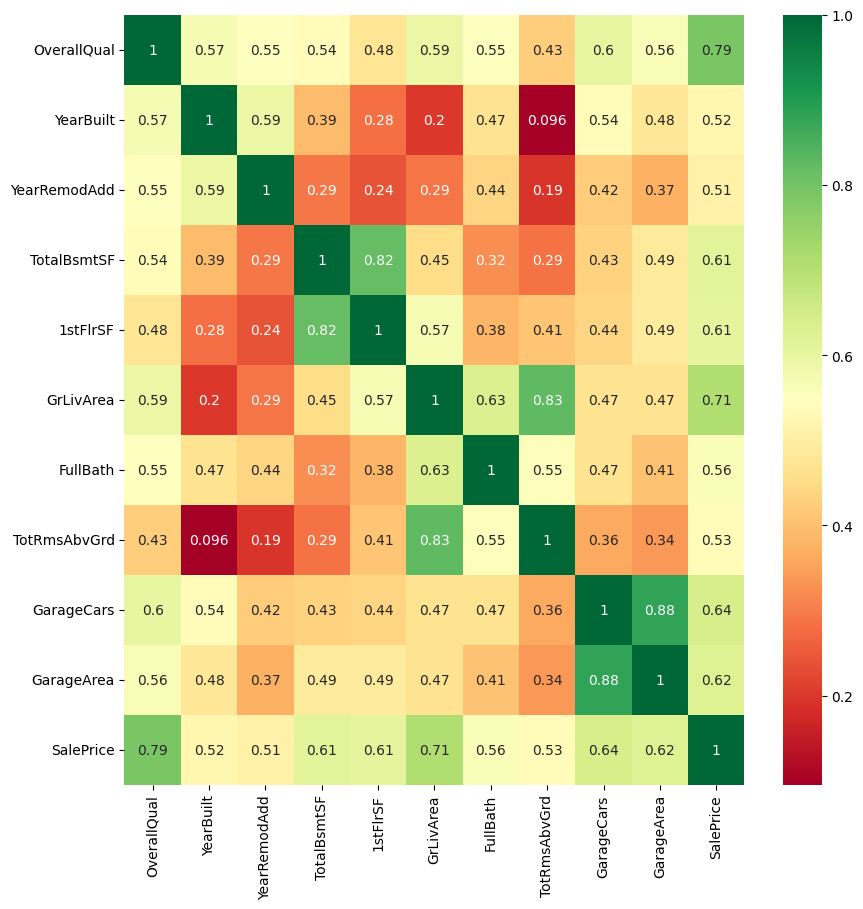

In [3]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
import matplotlib.pyplot as plt  # Matlab-style plotting
import seaborn as sns

from scipy import stats
from scipy.stats import norm, skew # for some statistics


# most correlated features
corrmat = home_data.select_dtypes(include=['number']).corr()
top_corr_features = corrmat.index[abs(corrmat["SalePrice"])>0.5]
plt.figure(figsize=(10,10))
g = sns.heatmap(home_data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

## Core Data definition

It's important to decide early on which columns are valuable.
I've fine-tuned this list as I've refined the models

In [4]:
# Define the list of core features to keep. This list includes both numerical
# and categorical features that are highly predictive.
core_features = [
    
    # Numerical
    'GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea', 'PoolArea', 'LotFrontage',
    '2ndFlrSF',
    'LowQualFinSF', 'BsmtUnfSF', '1stFlrSF',
    'WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch',
    
    # Counts/Totals
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'TotRmsAbvGrd', 'Fireplaces', 
   
    # Temporal - Dates
    'YearBuilt', 'YrSold', 'YearRemodAdd',

    # Quality/Condition (Ordinal/Categorical)
    'OverallQual', 'OverallCond','HeatingQC', 'BsmtQual', 'PoolQC',
    'ExterQual', 
    'KitchenQual', 'Functional', 
    'FireplaceQu','BsmtCond',
    'ExterCond',
    
    # OneHot (Categorical)
    'Neighborhood', 'MSZoning', 'MSSubClass', 
    'LandSlope', 'Alley', 'LandContour', 'BldgType', 
    'Condition1', 
    'RoofStyle', 
    'Foundation', 
    'SaleCondition', 'Exterior1st',
    'Utilities', 
    'Electrical',
    'GarageQual', 'GarageCond',
]

# Data Processing Steps

**We will be looking at:**
 * **Removing Outliers**
 * **Filling Missing Data**
 * **Engineered Features**
 * **Log Transformation (numerical)**
 * **Encoding Categorical - Unordered**
 * **Encoding Categorical - Ordered**


Below I've listed the function definitions.

These will need to be used both on the train/test split and on the full data, so it's easier to have them reusable.

***

**Disclaimer:**

I started with pandas, numpy code initially, then tried to switch to using pipelines.  Unfortunately I had stability issues with the columns due to the interaction between Engineered Features and Log Transformation.

Please excuse the mix of pandas and pipelines below &#x1F600;

## 1. Outlier Removal

I've identified GrLivAre and GarageArea as 2 columns with outliers.

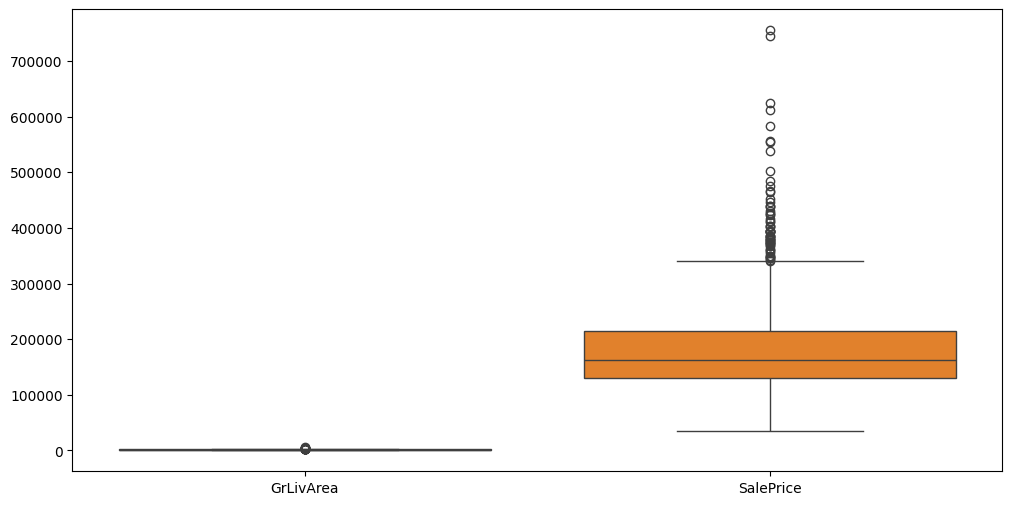

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=home_data[['GrLivArea', 'SalePrice']])
plt.show()

In [6]:
def outlier_removal(df_train,show_plots):

    # GrLivArea
    outlier_index = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)].index
    print(f"Indices of GrLivArea outliers to be removed: {outlier_index.tolist()}")
    df_train_cleaned = df_train.drop(outlier_index, axis=0)
    print(f"Number of rows after removal: {len(df_train_cleaned)}")

    # I also checked other potential outliers, but they influenced the score negatively. Eg: GarageArea
    # GarageArea
    # outlier_index = df_train_cleaned[(df_train_cleaned['GarageArea'] > 1200) & (df_train_cleaned['SalePrice'] < 300000)].index
    # print(f"Indices of GarageArea to be removed: {outlier_index.tolist()}")
    # df_train_cleaned = df_train_cleaned.drop(outlier_index, axis=0)
    # print(f"Number of rows after removal: {len(df_train_cleaned)}")

    return df_train_cleaned

In [7]:
# just a utility function we'll use to print the steps
def print_section_header(title):
    """Prints a title surrounded by a visual delimiter."""
    delimiter = "-" * 50  # 50 dashes
    print(delimiter)
    print(f"--- {title} ---")
    print(delimiter)

In [8]:
home_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
# missing cols
missing_cols = [col for col in home_data.columns if home_data[col].isna().sum() > 0]
missing_cols

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

## 2. Fill missing Data

For some columns we should fill in zeros, for others median values.

The biggest challenge was around Data Leakage.  
eg: The median values need to be calculated separately for the train / test split and not overall the whole training data.

In [10]:
def fill_missing(df_core):
    print("Filling missing value...")
    
    # Impute count/area features with 0
    fill_zero_cols = [
        'PoolArea', 'GrLivArea', 'LotArea', 
        'TotalBsmtSF', 'BsmtUnfSF',
        'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 
        '2ndFlrSF', 
        'LowQualFinSF', '1stFlrSF', '3SsnPorch', 
        'EnclosedPorch', 'ScreenPorch', 'WoodDeckSF', 'OpenPorchSF',
        'GarageArea',
    ]
    df_core[fill_zero_cols] = df_core[fill_zero_cols].fillna(0)
    return df_core

## 3. Engineered Features

The most usefull features I've found to be Quality quantifiers = SurfaceArea x SurfaceQuality

I'll leave commented out some of the other things I've tried.

Based on my experience this list isn't final and adding, removing features is also impacted by how **tuned** the models are. eg: If the model is already overfit, adding any feature would lower the score.

In [11]:
def add_engineered_features(df_core):
    print("Adding Engineered Features...")
    
    df_core['TotalSF'] = df_core['GrLivArea'] + df_core['TotalBsmtSF'] # sum areas
    df_core['TotalQualSF'] = df_core['TotalSF'] * df_core['OverallQual'] # quality quantifiers
    df_core['TimeSinceRemod'] = df_core['YrSold'] - df_core['YearRemodAdd']
    df_core['Age'] = df_core['YrSold'] - df_core['YearBuilt']
    df_core['InteriorQualityScore'] = df_core['GrLivArea'] * df_core['OverallQual']
    
    df_core['TotalBaths'] = ( df_core['FullBath'] + (0.5 * df_core['HalfBath']) + 
                              df_core['BsmtFullBath'] + (0.5 * df_core['BsmtHalfBath']))
    porch_deck_cols = [
        'WoodDeckSF','OpenPorchSF',
        'EnclosedPorch','3SsnPorch',
        'ScreenPorch'
    ]
    df_core['HasPorchDeck'] = (df_core[porch_deck_cols].sum(axis=1) > 0).astype(int)
    df_core['TotalPorchDeckSF'] = df_core[porch_deck_cols].sum(axis=1)


    # here are some other features i've tried

    #df_core['GrLivAreax2'] = df_core['GrLivArea'] ** 2
    #df_core['OverallQualx2'] = df_core['OverallQual'] ** 2
    #df_core['TotalSFAge'] = df_core['TotalSF'] * df_core['Age']
    #df_core['TotalBsmtSFx2'] = np.log1p(df_core['TotalBsmtSF']) ** 2
    #df_core['PorchDeckQL'] = df_core['OverallQual'] + df_core['TotalPorchDeckSF']
    #df_core['TotalSFx2'] = np.log1p(df_core['TotalSF']) ** 2
    #df_core['HasPool'] = np.where(df_core['PoolArea'] > 0, 1, 0)
    #df_core['HasBasement'] = (df_core['TotalBsmtSF'] > 0).astype(int)
    #df_core['PorchDeckQL'] = df_core['OverallQual']* df_core['TotalPorchDeckSF']
    #df_core['BSM_QL_Score'] = df_core['TotalBsmtSF'] * df_core['BsmtQual_Encoded']
    #df_core['TotalSF_sq'] = df_core['TotalSF'] ** 2
    #df_core['IsNew'] = np.where(df_core['YearBuilt'] == df_core['YrSold'], 1, 0)
    #df_core['OverallGrade'] = df_core['OverallQual'] * df_core['OverallCond']
    
    # safe_tot_rooms = df_core['TotRmsAbvGrd'].replace(0, 1) 
    # df_core['AreaPerRoom'] = df_core['TotalSF'] / safe_tot_rooms   

    # df_core['IsRecentRemod'] = np.where(
    # (df_core['YrSold'] - df_core['YearRemodAdd']) <= 10,
    # 1,  # Value if True (recently remodeled)
    # 0   # Value if False
    # )


    # I've read that it's a best practice to drop the features that are used in engineering.
    # the concept is colinearity, where noise is introduced if there are multiple related features 
    # In this personal case, dropping columns actually lowered my score so I've kept them.
    drop_components = [
        #'WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch',
        #'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 
        #'YearRemodAdd', 
        #'YrSold',
        #'YearBuilt', 
        #'OverallQual', 
    ]
    df_core = df_core.drop(columns=[c for c in drop_components if c in df_core.columns], )

    return df_core

## 4. Log Transform

This basically means lowering the numbers so that individual features have comparable values.  
I think the intuition is if the value ranges are comparable, changing an individual weight does not bias the algorithm toward a specific feature being more important.

Another related concepts is: standardization. I used that for the linear models since they are more sensitive to it.

One important thing I've learned, is that logTransform fixes right skew only. When I appleid it to left skewed columns it made the prediction worse.

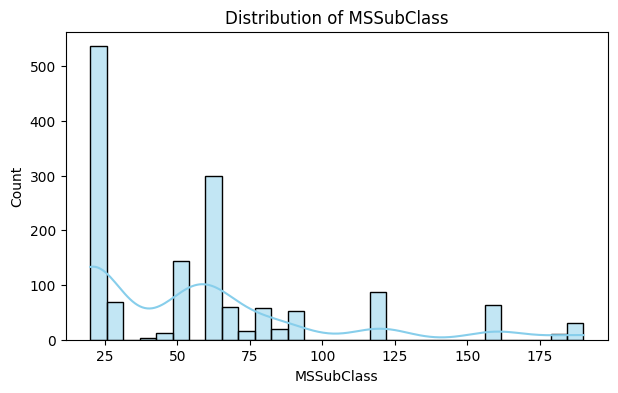

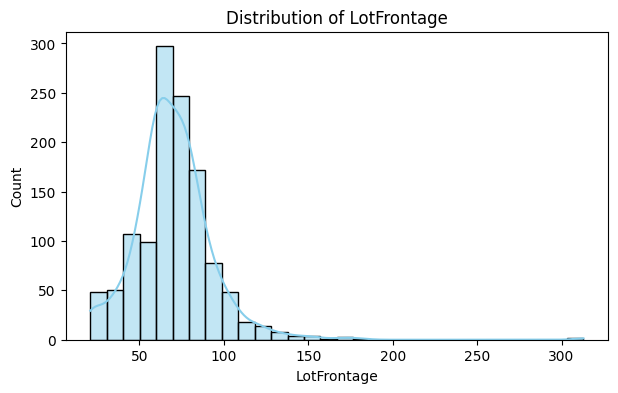

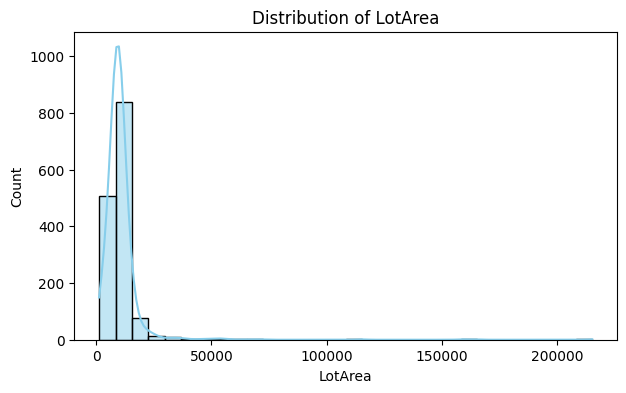

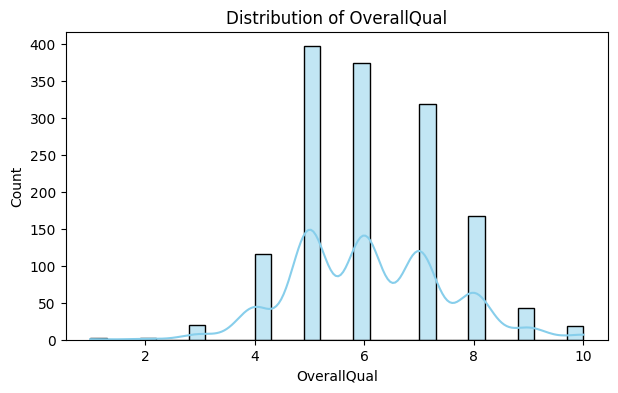

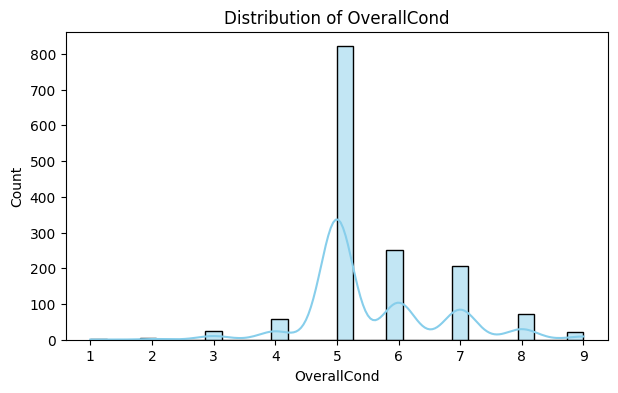

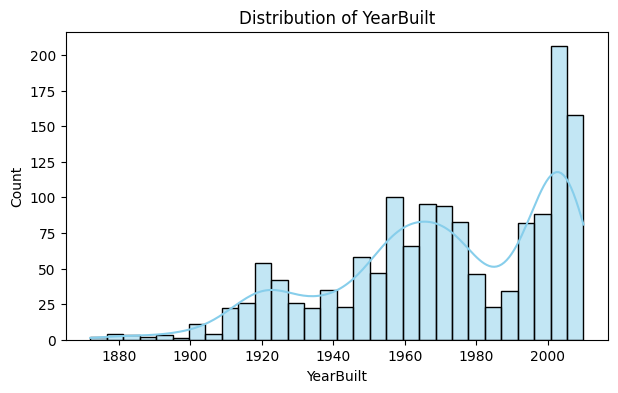

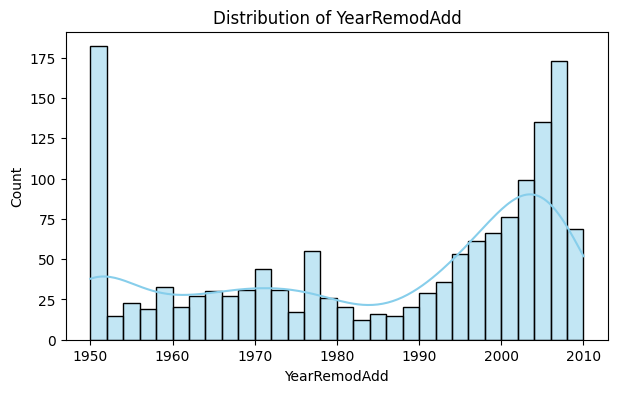

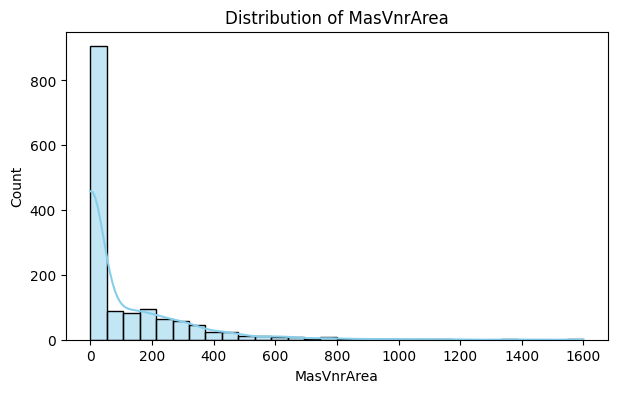

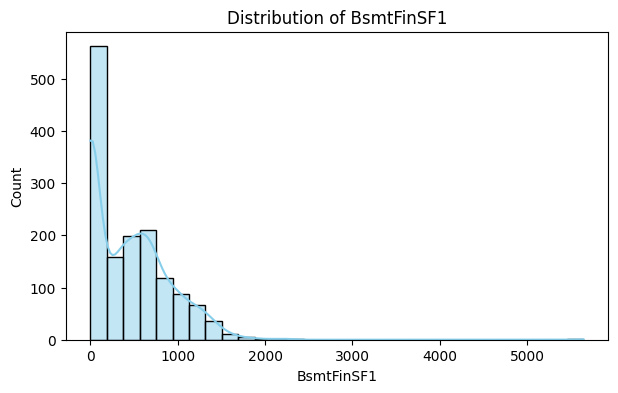

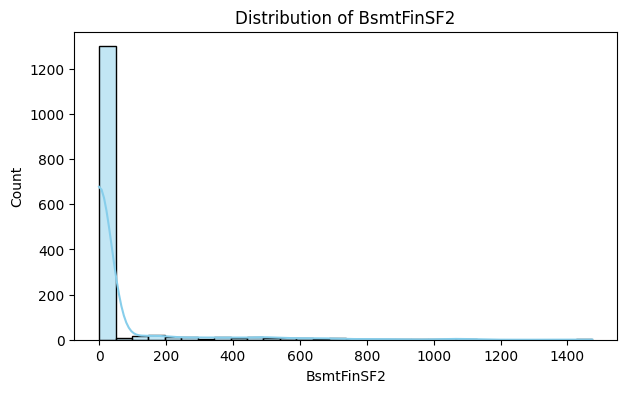

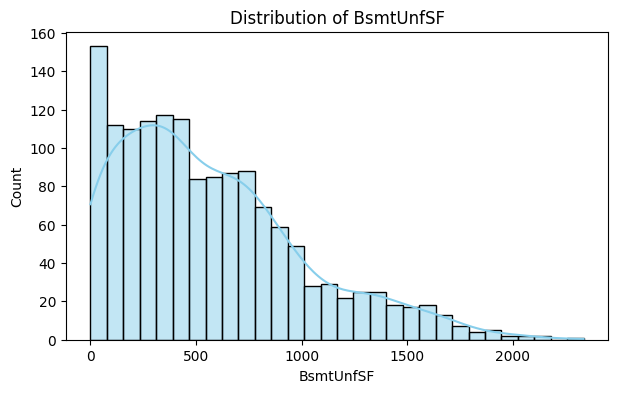

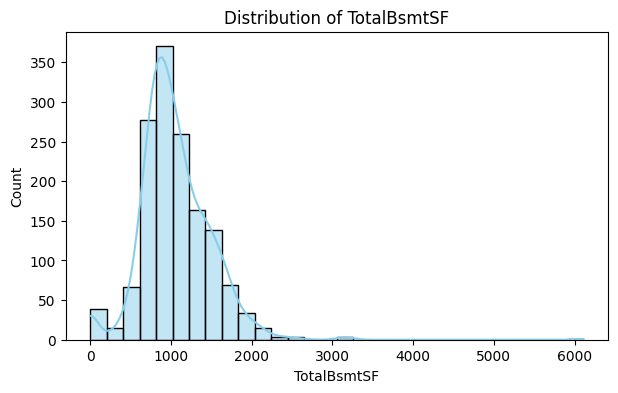

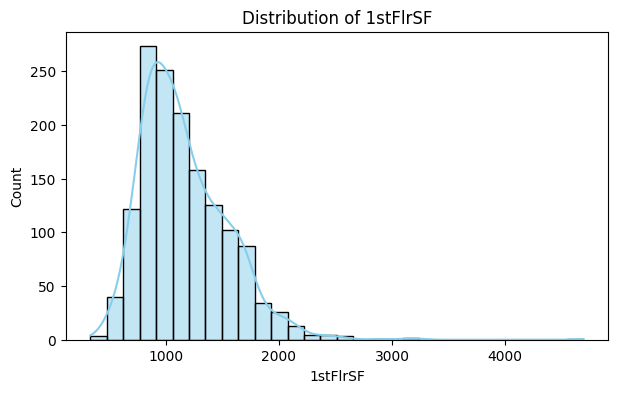

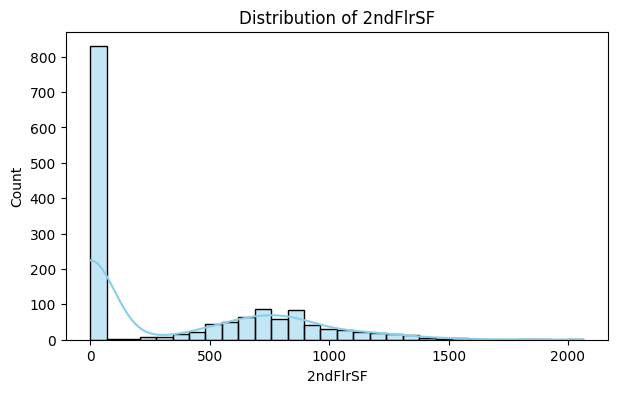

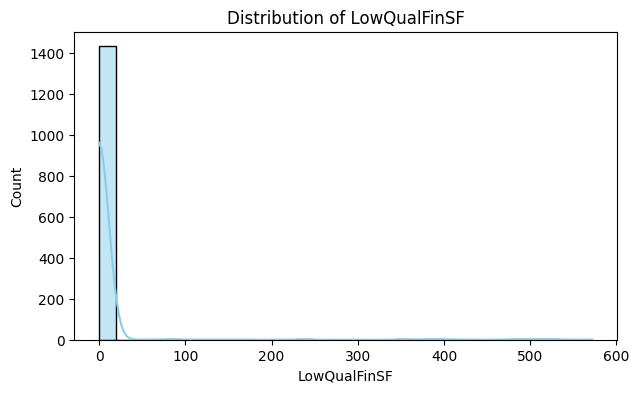

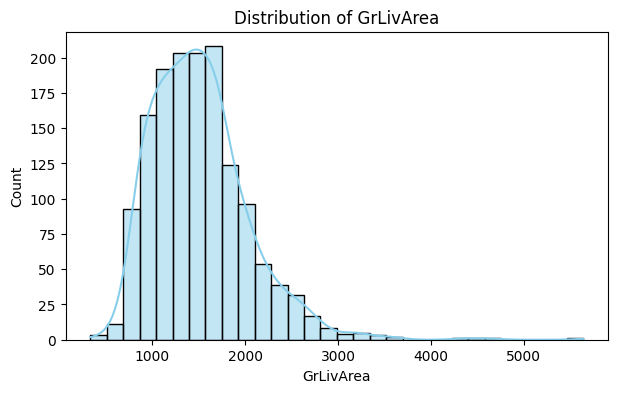

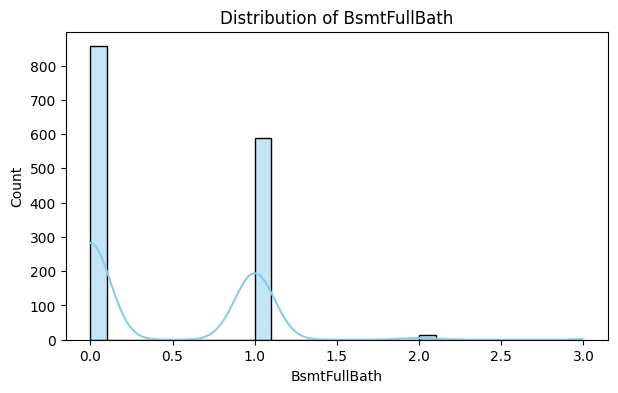

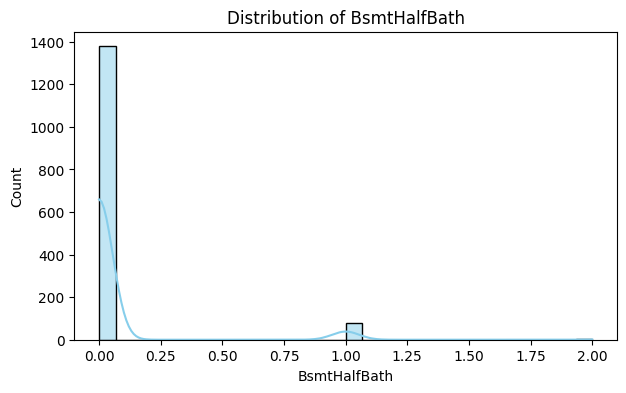

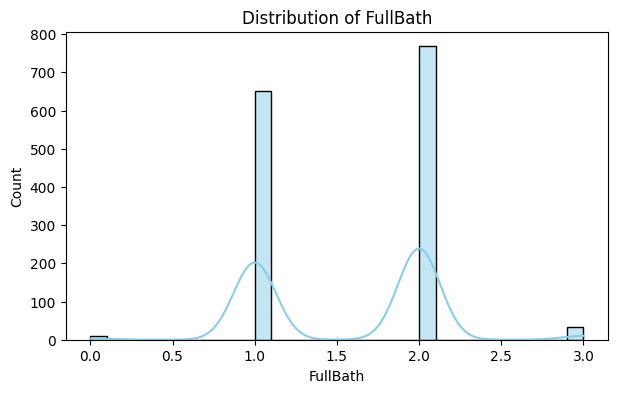

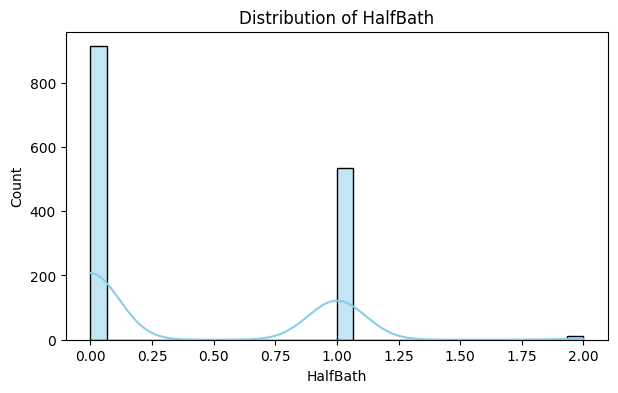

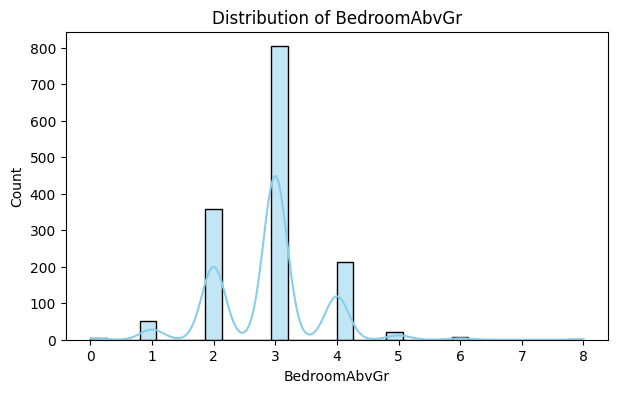

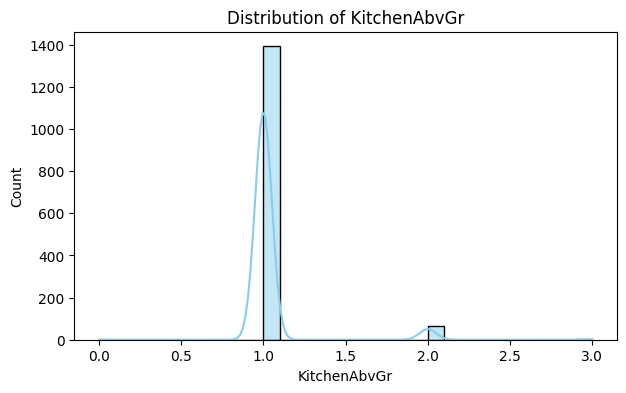

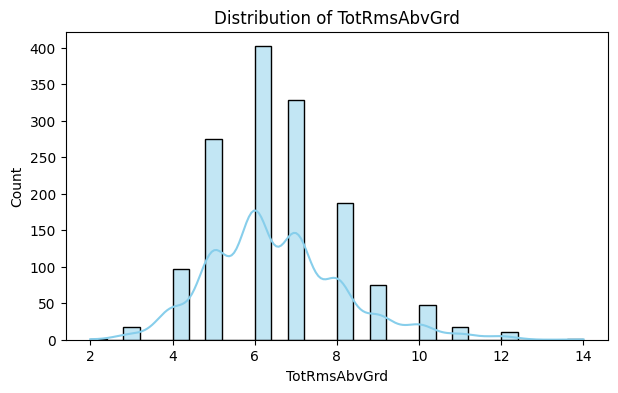

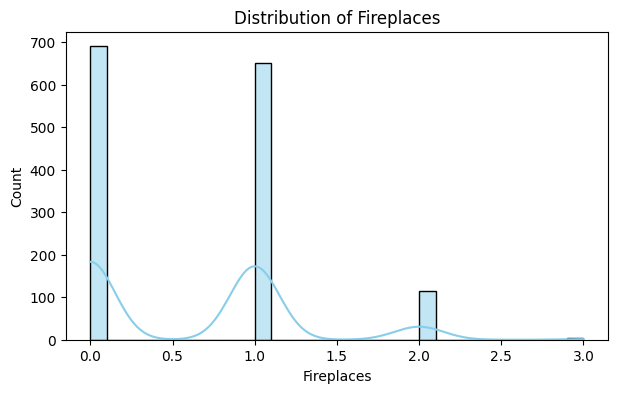

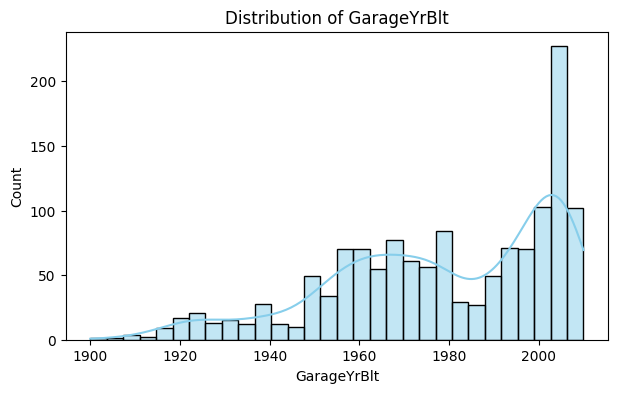

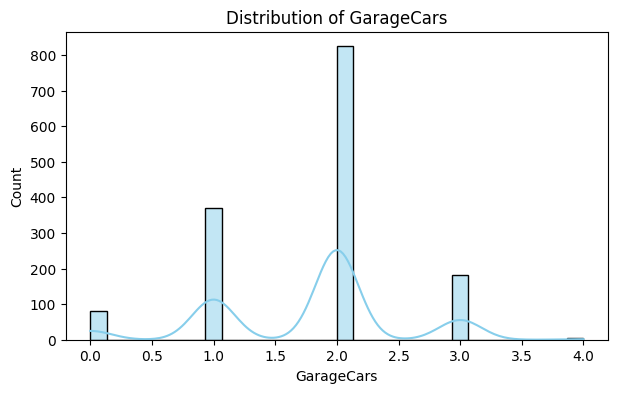

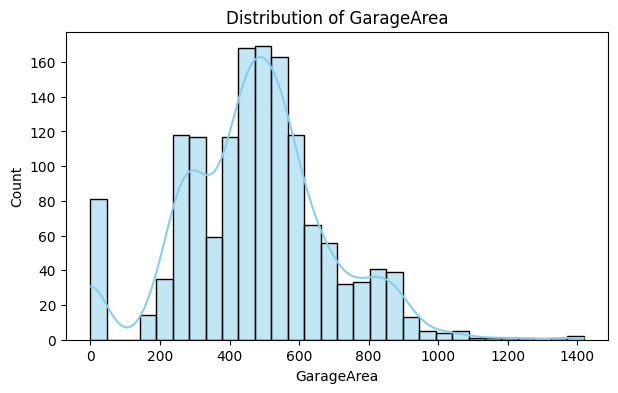

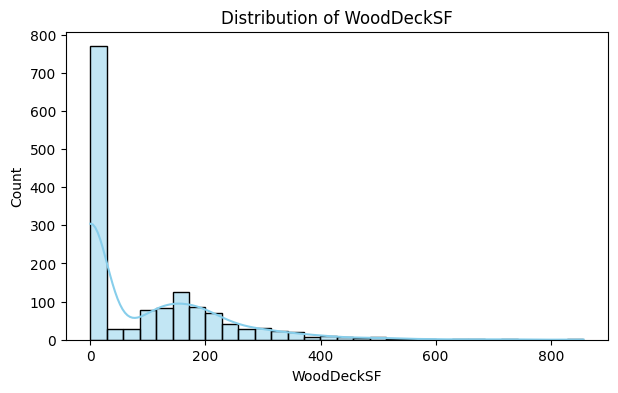

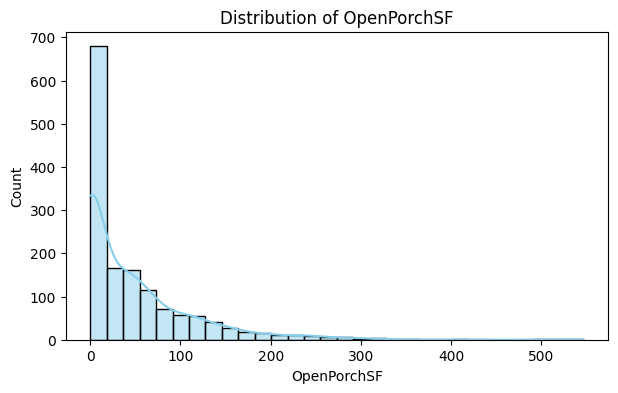

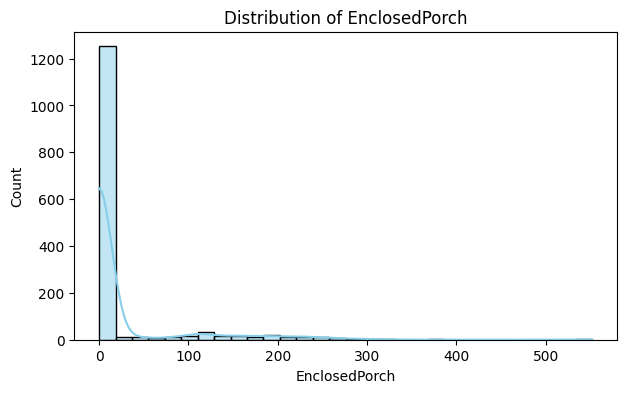

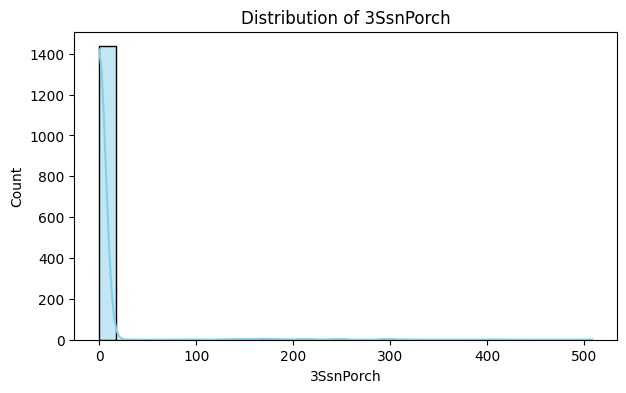

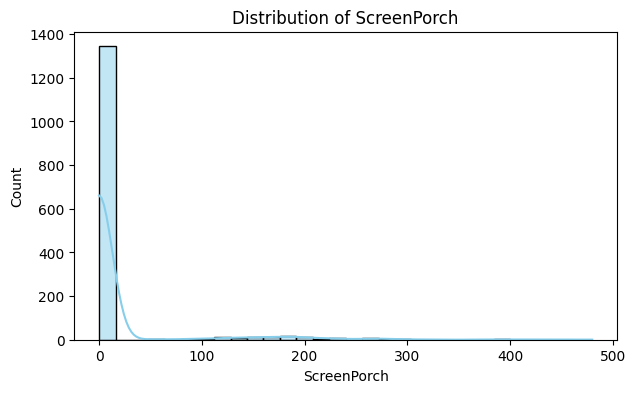

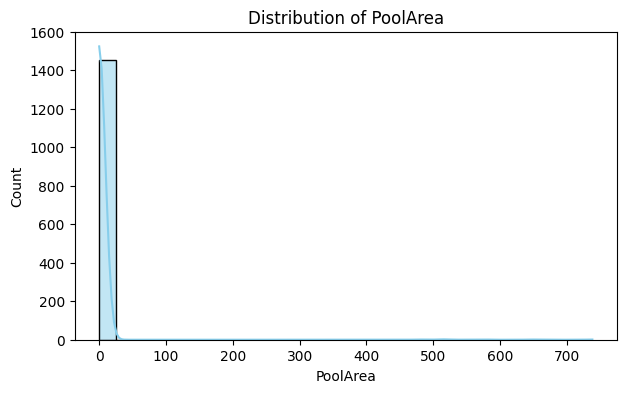

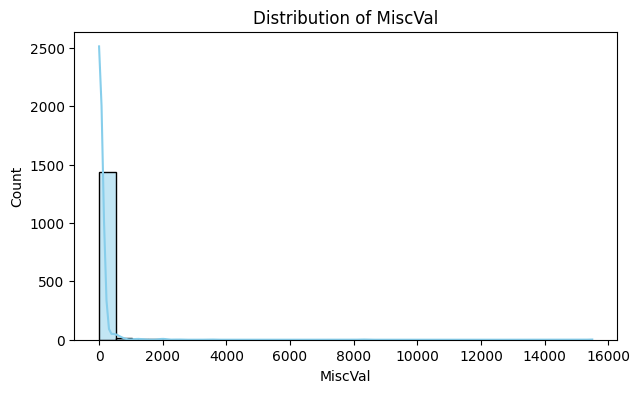

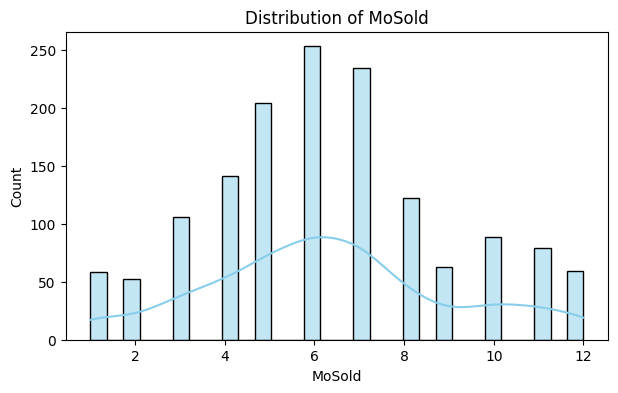

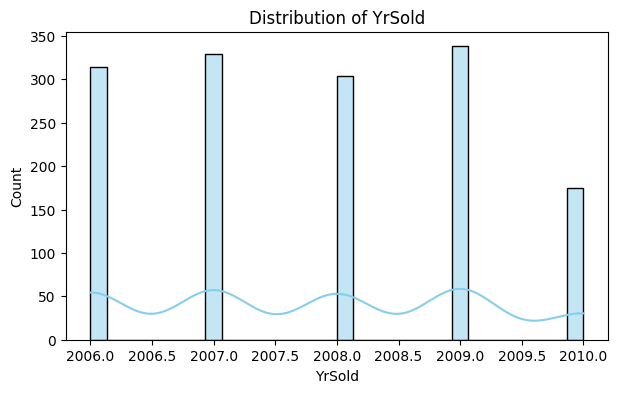

In [12]:
numeric_cols = home_data.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols[1: -1]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(home_data[col], bins=30, kde=True, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [13]:
def logTransformFeatures(df_core):
    #show_skewed_cols(df_core)
    
    print("Transforming features log1p...")

    skewed_features = [
        'LotArea',
        'PoolArea',
        'LowQualFinSF',
        'BsmtHalfBath',

        'GrLivArea', 
       # 'TotalBsmtSF',
        'LotFrontage',
        '1stFlrSF',
        '2ndFlrSF', 
        'BsmtUnfSF', 
        'TotalSF',
        'TotalQualSF',
        'InteriorQualityScore',
       # 'TotalPorchDeckSF',
    ]

    
    # np.log1p(x) is equivalent to np.log(1 + x) and handles zero values gracefully.
    for col in skewed_features:
        # Ensure the column exists before transforming
        if col in df_core.columns:
            df_core[col] = np.log1p(df_core[col])

    return df_core

## 5. One Hot Encode - Categorical - Unordered

In [14]:
OHE_CATEGORICAL_COLS = [
    'Neighborhood', 'MSZoning', 'LandSlope', 'Alley', 'LandContour', 'BldgType',
    'Condition1', 
    'RoofStyle', 
    'Foundation', 
    'SaleCondition', 
    'Exterior1st', 
    'Utilities', 
    'Electrical',
    'GarageQual', 
    'GarageCond',
]

categorical_pipeline = Pipeline(steps=[
    # replace actual NaNs with 'missing' so it's it's own category
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    
    # One Hot Encode
    ('onehot', OneHotEncoder(
        handle_unknown='infrequent_if_exist',
      #  handle_unknown='ignore', # Safely handles categories seen in test but not in train (outputs 0s)
        min_frequency=0.03, # this alternative strategy gave better results for me
        sparse_output=False, 
        drop='first' 
    ))
])

# This applies the OHE pipeline only to the specified columns.
ohe_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, OHE_CATEGORICAL_COLS)
    ],
    remainder='passthrough', # Keeps all other columns (numerical, etc.) untouched
    verbose_feature_names_out=False 
).set_output(transform="pandas")


## 6. Encode - Categorical - Ordered

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
import numpy as np

# --- 1. Define Categories by Order (Lowest to Highest Rank) ---

# Standard Quality Map: Po (1) < Fa (2) < TA (3) < Gd (4) < Ex (5)
# 'None' or np.nan will be the lowest rank (0).
QUALITY_ORDER = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

# Functional Map: Sal (1) < Sev (2) < ... < Typ (8)
FUNCTIONAL_ORDER = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']


# --- 2. Define the Column Groups ---
quality_cols = ['FireplaceQu', 'BsmtCond', 'KitchenQual', 'ExterQual', 
                'HeatingQC', 'BsmtQual', 'PoolQC', 'ExterCond']
functional_cols = ['Functional']


# --- 3. Define the Ordinal Transformer ---
# The imputers replace NaNs (or 'NA' after a replace step) with a string 'None' 
# so the OrdinalEncoder can assign it the rank 0.

ordinal_transformer = ColumnTransformer(
    transformers=[
        # A. Standard Quality Features
        ('quality_enc', Pipeline([
            # Impute NaNs with 'None' string to be treated as rank 0
            ('imputer', SimpleImputer(strategy='constant', fill_value='None')), 
            ('ordinal', OrdinalEncoder(
                categories=[['None'] + QUALITY_ORDER] * len(quality_cols),
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ))
        ]), quality_cols),
        
        # D. Functional Feature
        ('functional_enc', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
            ('ordinal', OrdinalEncoder(categories=[['None'] + FUNCTIONAL_ORDER], 
                                       unknown_value=-1, 
                                       handle_unknown='use_encoded_value'))
        ]), functional_cols),       
    ],
    remainder='passthrough'
)

## 7. Handling the median calculation problem

I faced significant column stability issues when trying to pipeline all complex preprocessing steps, so I used a custom ManualFeatureProcessor to stabilize the data flow.  
This custom step handles critical tasks like feature engineering and learning statistics (e.g., the median) first on the training data.  
This ensures the model prevents data leakage and maintains column order, allowing the scikit-learn pipeline to handle final encoding and scaling without errors.

ps: I asked AI for help with this, so, thank you Gemini!

In [16]:
class ManualFeatureProcessor:
    def __init__(self):
        self.imputation_values = {}
    

    def fit(self, X):
        # 1. Learn median for LotFrontage (or other imputed values)
        if 'LotFrontage' in X.columns:
             self.imputation_values['LotFrontage'] = X['LotFrontage'].median()

        # 2. Learn median for YearBuilt (YearImputer logic)
        if 'YearBuilt' in X.columns:
            self.imputation_values['YearBuilt_median'] = X['YearBuilt'].median()

        if 'YrSold' in X.columns:
            self.imputation_values['YrSold_mode'] = X['YrSold'].mode()[0]

    def transform(self, X):
        X_copy = X.copy()
        
        # 1. APPLY Imputation (e.g., using learned median)
        if 'LotFrontage' in self.imputation_values:
            X_copy['LotFrontage'] = X_copy['LotFrontage'].fillna(self.imputation_values['LotFrontage'])

        if 'YearBuilt_median' in self.imputation_values:
            median_year = self.imputation_values['YearBuilt_median']
            X_copy['YearBuilt'] = X_copy['YearBuilt'].fillna(median_year)

            # B. Impute YearRemodAdd using the NOW-IMPUTED YearBuilt
            X_copy['YearRemodAdd'] = X_copy['YearRemodAdd'].fillna(X_copy['YearBuilt'])

        if 'YrSold_mode' in self.imputation_values:
            mode_year = self.imputation_values['YrSold_mode']
            X_copy['YrSold'] = X_copy['YrSold'].fillna(mode_year)

        X_copy['Utilities'] = X_copy['Utilities'].fillna('AllPub')
     
        X_copy = fill_missing(X_copy) # fill missing values
        X_copy = add_engineered_features(X_copy) # ENGINEERED FEATURES
        X_copy = logTransformFeatures(X_copy) # LOG Transform

        return X_copy

# Training on split data 80 / 20

## 1. Applying the manual data preprocessing 

Part of the data transformation is manual and wrapped in ManualFeatureProcessor.
- outlier removal
- fill missing data
- feature engineering
- log transform

I will also create a reusable pipeline since we will be testing multiple models!

In [17]:
print_section_header("Training on split data 80 / 20")

home_data = outlier_removal(home_data, False)

y = np.log1p(home_data.SalePrice) # log transform sales price
X = home_data[core_features].copy() # clone home_data

# Split into validation and training data
train_X_raw, val_X_raw, train_y, val_y = train_test_split(X, y, random_state=1 )
print("Creating train / test split...")

# 2. Initialize and FIT the manual processor on the RAW TRAINING DATA
manual_processor = ManualFeatureProcessor()
manual_processor.fit(train_X_raw)

# 3. TRANSFORM both datasets using the statistics learned from TRAIN
train_X = manual_processor.transform(train_X_raw)
val_X = manual_processor.transform(val_X_raw)


# reusable pipeline since I got tired of typing it in each model
feature_pipeline = Pipeline(steps=[
    ('ohe_proc', ohe_preprocessor),
    ('ordinal_prep', ordinal_transformer),
])

--------------------------------------------------
--- Training on split data 80 / 20 ---
--------------------------------------------------
Indices of GrLivArea outliers to be removed: [523, 1298]
Number of rows after removal: 1458
Creating train / test split...
Filling missing value...
Adding Engineered Features...
Transforming features log1p...
Filling missing value...
Adding Engineered Features...
Transforming features log1p...


## 2. Gradient Boost Regressor - Tree

**The individual model logic is as follows:**
- define the pipeline ( how to transform the data for the model)
- instantiate baseline model
- setup GridSearchCV and model param ranges to allow fine-tuning
- train the model via GridSearch to learn the best params

**Personal note on hyper-parameter tuning:**  
   - first started with learning rate and number of iterations / trees
   - i moved on to regularization params next

In [18]:
# ===================================================================
# MODEL 1: GRADIENT BOOSTING REGRESSOR (GBR)
# ===================================================================

print("⏳ Starting GBR REGRESSOR")

gbr_pipeline = Pipeline(steps=[
    ('features', feature_pipeline),
    ('regressor', GradientBoostingRegressor(random_state=1, verbose=0))
])

gbr_param_grid = {
    'regressor__n_estimators': [5000],
    'regressor__learning_rate': [0.03],
    'regressor__min_samples_leaf': [1],
    'regressor__min_samples_split': [2],
    'regressor__max_depth': [3],
    'regressor__subsample': [0.83],
    'regressor__max_features': ['sqrt'],
    'regressor__loss':['huber']
}


gbr_grid_search = GridSearchCV(
    estimator=gbr_pipeline,  # Use the pipeline as the estimator
    param_grid=gbr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

gbr_grid_search.fit(train_X, train_y) 
gbr_best_model = gbr_grid_search.best_estimator_

gbr_predictions_log = gbr_best_model.predict(val_X)

print("✅ Training complete!")

⏳ Starting GBR REGRESSOR


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 12, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✅ Training complete!


## 3. X-Boost Regressor - Tree

**The individual model logic is as follows:**
- define the pipeline ( how to transform the data for the model)
- instantiate baseline model
- setup GridSearchCV and model param ranges to allow fine-tuning
- train the model via GridSearch to learn the best params

**Personal note on hyper-parameter tuning:**  
   - first started with learning rate and number of iterations / trees
   - i moved on to regularization params next

In [19]:
# # ===================================================================
# # MODEL 2: XGBOOST REGRESSOR
# # ===================================================================

print("⏳ Starting XGBOOST REGRESSOR")

xgb_pipeline = Pipeline(steps=[
    ('features', feature_pipeline),
    ('regressor', xgb.XGBRegressor(
        objective='reg:squarederror', 
        random_state=1, 
        n_jobs=-1, 
        verbosity=0,
    ))
])

xgb_param_grid = {
    'regressor__n_estimators': [3900],
    'regressor__learning_rate': [0.004],
    'regressor__max_depth': [5],
    'regressor__subsample': [0.7],
    'regressor__colsample_bytree': [0.8],
    'regressor__reg_alpha': [0.1], # L1 Regularization
    #'regressor__reg_lambda': [0.001] # L2 Regularization
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

xgb_grid_search.fit(train_X, train_y)
xgb_best_model = xgb_grid_search.best_estimator_

xgb_predictions_log = xgb_best_model.predict(val_X)

print("✅ Training complete!")

⏳ Starting XGBOOST REGRESSOR


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 12, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✅ Training complete!


## 4. Lasso Regressor - Linear

**The individual model logic is as follows:**
- define the pipeline ( how to transform the data for the model)
- instantiate baseline model
- setup GridSearchCV and model param ranges to allow fine-tuning
- train the model via GridSearch to learn the best params

**Personal note on hyper-parameter tuning:**  
   - first started with learning rate and number of iterations / trees
   - i moved on to regularization params next

In [20]:
# # ===================================================================
# # MODEL 3: LASSO REGRESSION
# # ===================================================================

print("⏳ Starting LASSO REGRESSION")

lasso_pipeline = Pipeline(steps=[
    ('features', feature_pipeline),
    ('scaler', StandardScaler()), # important for linear models
    ('lasso', Lasso(random_state=1, max_iter=50000))
])

lasso_param_grid = {
    'lasso__alpha': [0.0001] 
    # cool note, we can use  np.logspace(-5, -3, 5) to generate arrays with powers of 10
}

lasso_grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

lasso_grid_search.fit(train_X, train_y)
lasso_best_model = lasso_grid_search.best_estimator_

lasso_predictions_log = lasso_best_model.predict(val_X)

print("✅ Lasso Training complete!")

⏳ Starting LASSO REGRESSION


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 12, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✅ Lasso Training complete!


## 5. Kernel Ridge - Non Linear

**The individual model logic is as follows:**
- define the pipeline ( how to transform the data for the model)
- instantiate baseline model
- setup GridSearchCV and model param ranges to allow fine-tuning
- train the model via GridSearch to learn the best params

**Personal note on hyper-parameter tuning:**  
I focused my tuning on the **regularization strength ($\alpha$)** and the **kernel width ($\gamma$)**, as these directly control the model's complexity and flexibility. 

In [21]:
from sklearn.kernel_ridge import KernelRidge

print("⏳ Starting Kernel Ridge REGRESSION")

krr_pipeline = Pipeline(steps=[
    ('features', feature_pipeline),
    ('scaler', StandardScaler()),
    ('krr', KernelRidge(kernel='rbf'))
])

krr_param_grid = {
    # Alpha controls regularization
    'krr__alpha': [0.0003],
    # Gamma controls the kernel width
    'krr__gamma': [0.0001],
}

krr_grid_search = GridSearchCV(
    estimator=krr_pipeline,  # Use the full KRR pipeline as the estimator
    param_grid=krr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

krr_grid_search.fit(train_X, train_y) 

krr_best_model = krr_grid_search.best_estimator_
krr_best_params = krr_grid_search.best_params_

krr_predictions_log = krr_best_model.predict(val_X)

print("✅ Kernel Ridge Training complete!")

⏳ Starting Kernel Ridge REGRESSION


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 12, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✅ Kernel Ridge Training complete!


## Cat Boost

In [22]:
# ===================================================================
# MODEL 5: CATBOOST REGRESSOR
# ===================================================================
from catboost import CatBoostRegressor # NEW: Import CatBoost

print("⏳ Starting CATBOOST REGRESSOR")

cat_pipeline = Pipeline(steps=[
    ('features', feature_pipeline),
    ('regressor', CatBoostRegressor(
        random_state=1,
        verbose=0,
        loss_function='RMSE',
    ))
])

cat_param_grid = {
    'regressor__n_estimators': [1900], 
    'regressor__learning_rate': [0.02],
    'regressor__depth': [6],
    'regressor__l2_leaf_reg': [3], # L2 regularization coefficient
    'regressor__subsample': [0.7], # Fraction of samples to be used for fitting the trees
    'regressor__colsample_bylevel': [0.7], # Fraction of features to be considered at each split
}

cat_grid_search = GridSearchCV(
    estimator=cat_pipeline,
    param_grid=cat_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

cat_grid_search.fit(train_X, train_y)
cat_best_model = cat_grid_search.best_estimator_

cat_predictions_log = cat_best_model.predict(val_X)

print("✅ CatBoost Training complete!")

⏳ Starting CATBOOST REGRESSOR


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 12, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✅ CatBoost Training complete!


## 6. Compare individual models

Basically here we compare the predicted vs actual values.
The goal is to be able to choose the models that will go into our Meta Modeler.

I'm looking at:
 - individual model scores
 - combinations of model scores via averaging

Once I see a promising combination, I use that via a meta learner so it learns the weights for each model.
It's basically like finding the params for the optimal weighted average

In [23]:

# ===================================================================
# 2. Comparison and Evaluation
# ===================================================================

print("\n" + "="*20 + " Model Comparison " + "="*20)

# util function, prins MSLE and MAE on actual vs predicted
def evaluate_model(predictions_log, val_y, name, grid_search_object=None):
    rmsle = np.sqrt(mean_squared_error(predictions_log, val_y))
    predictions_actual = np.expm1(predictions_log)
    val_y_actual = np.expm1(val_y)
    mae = mean_absolute_error(predictions_actual, val_y_actual)

    params_output = (
        grid_search_object.best_params_
        if grid_search_object is not None
        else "N/A (Ensemble)"
    )
    
    print(f"\n--- {name} Results ---")
    print(f"Optimal Params: {params_output}")
    print(f"Validation RMSLE: {rmsle:.4f}")
    print(f"Validation MAE: ${mae:,.0f}")  

# Evaluate CatBoost
evaluate_model(cat_predictions_log, val_y, "CatBoost", cat_grid_search)

# Evaluate Lasso
evaluate_model(lasso_predictions_log, val_y, "Lasso", lasso_grid_search)

# Evaluate GBR
evaluate_model(gbr_predictions_log, val_y, "GradientBoostRegressor", gbr_grid_search)

# Evaluate XGBoost
evaluate_model(xgb_predictions_log, val_y, "XGBoost", xgb_grid_search)

# Evaluate KR
evaluate_model(krr_predictions_log, val_y, "Kernel Ridge", krr_grid_search)


# Evaluate different ensambles
evaluate_model((xgb_predictions_log + gbr_predictions_log + lasso_predictions_log) / 3, val_y, "Ensemble: XGB - GBR - Lasso")

evaluate_model((xgb_predictions_log + cat_predictions_log + krr_predictions_log) / 3, val_y, "Ensemble: XGB - CAT - KRR")

evaluate_model((cat_predictions_log + gbr_predictions_log + krr_predictions_log) / 3, val_y, "Ensemble: CAT - GBR - KRR")


evaluate_model((xgb_predictions_log + lasso_predictions_log + krr_predictions_log) / 3, val_y, "Ensemble: XGB - Lasso - KRR")

evaluate_model((xgb_predictions_log + lasso_predictions_log + gbr_predictions_log + krr_predictions_log) / 4, val_y, "Ensemble: XGB - GBR - Lasso - KRR")


# This is an example of what we're trying to learn with the meta-modeler
weight_X = 0.26  # XGBoost weight
weight_G = 0.57  # GBR weight
weight_L = 0.17  # Lasso provides regularization/diversity, but less raw power
# Ensure weights sum to 1.0
print(weight_X + weight_G + weight_L)
if abs((weight_X + weight_G + weight_L) - 1.0) >= 1e-9:
    print('Error')

ensemble_predictions_log_weighted = (
    (weight_X * xgb_predictions_log) + 
    (weight_G * gbr_predictions_log) + 
    (weight_L * lasso_predictions_log)
)

# Evaluate the 3-model Ensemble
evaluate_model(ensemble_predictions_log_weighted, val_y, "Ensemble: XGB - GBR - Lasso - Custom Weighted (3-Avg)")


==================== Model Comparison ====================

--- CatBoost Results ---
Optimal Params: {'regressor__colsample_bylevel': 0.7, 'regressor__depth': 6, 'regressor__l2_leaf_reg': 3, 'regressor__learning_rate': 0.02, 'regressor__n_estimators': 1900, 'regressor__subsample': 0.7}
Validation RMSLE: 0.1164
Validation MAE: $12,793

--- Lasso Results ---
Optimal Params: {'lasso__alpha': 0.0001}
Validation RMSLE: 0.1264
Validation MAE: $14,861

--- GradientBoostRegressor Results ---
Optimal Params: {'regressor__learning_rate': 0.03, 'regressor__loss': 'huber', 'regressor__max_depth': 3, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 5000, 'regressor__subsample': 0.83}
Validation RMSLE: 0.1177
Validation MAE: $13,027

--- XGBoost Results ---
Optimal Params: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.004, 'regressor__max_depth': 5, 'regressor__n_estimators': 3900, 'regressor__reg

## 7. Combining Models - Meta Modeler

The intuition here is to combine different models as each has his own strengths, weaknesses.
Some are more prone to overfitting, others to underfitting
Some capture more complex relationships easier.

The strategy is to use a Linear model to learn the weights of each individual model so that we get
a stacking/blending average that gives the best of all worlds.

**Important**
 The competition states they are looking at RMSLE, but my experience on the leaderboard is it's actually ranking by MAE, so I chose to tune this last step prioritizing MAE. 

**Note**
  This area is very finicky.
  Once I had tuned the individual models for the best fit, I had to actually relax the fit to get a better score.
  I either increased the learning rate or tuned the regularization params to dial things back.
  

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


NFOLDS = 5
kf = KFold(n_splits=NFOLDS, shuffle=True, random_state=1)

estimators = [
    ('gbr', gbr_best_model), # the gbr implementation gave in this case better results that xgb
    #('xgb', xgb_best_model),
    ('cat', cat_best_model), 
    #('lasso', lasso_best_model), # this gave worse results for me
    ('krr', krr_best_model), # Include the newly tuned KRR
]

# good old gradient descent 
# i looked at squared_error and elasticnet as well
sgd_meta_model = SGDRegressor(
    loss='epsilon_insensitive', 
    epsilon=0.0, # Setting epsilon to 0.0 makes it equivalent to MAE (Median Regression)
    penalty='l2', 
    learning_rate='invscaling',  # This implements the inverse scaling decay
    eta0=0.01,                   # The initial learning rate (alpha0)
    power_t=0.24,                 # The decay exponent (default is 0.25)
    alpha=0.001,
  #  momentum=0.9,                # Enables momentum (beta=0.9)
   # nesterov=True,               # Use Nesterov Accelerated Gradient (a variant of momentum)
    random_state=1
)

# Define the Meta-Regressor with Scaling using the MAE-optimized SGDRegressor
final_estimator_with_scaling = make_pipeline(
    StandardScaler(),
    sgd_meta_model
)

# 3. Define the Stacking Model
# The StackingRegressor handles all cross-validation and blending internally. cv=kf
stack = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator_with_scaling,
    cv=kf,
    n_jobs=-1,
    passthrough=False,
    verbose=0
)

print("Started training Simple Stacking Meta-Model...")
stack.fit(train_X, train_y)

# 4. Predict and Evaluate
stacking_predictions_log = stack.predict(val_X)

evaluate_model(
    stacking_predictions_log, 
    val_y, 
    "Stacking (SGD Meta)"
)

Started training Simple Stacking Meta-Model...


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 8, 10, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:2


--- Stacking (SGD Meta) Results ---
Optimal Params: N/A (Ensemble)
Validation RMSLE: 0.1166
Validation MAE: $13,083


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 8, 10, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Train on full data

We want to train the models on the full data so they have a better chance of succeeding.  
Important to note here the manual transformation being applied again.

In [25]:
print_section_header("Training on full data")

manual_processor = ManualFeatureProcessor()
manual_processor.fit(X)

x_fit = manual_processor.transform(X)

for name, model in estimators:
    print(f'Fitting {name} on full data')
    model.fit(x_fit,y)

print("Training SGD regressor (log target)...")
stack.fit(x_fit, y)

# Store the exact order of the columns used in fit()
training_columns = X.columns.tolist()

--------------------------------------------------
--- Training on full data ---
--------------------------------------------------
Filling missing value...
Adding Engineered Features...
Transforming features log1p...
Fitting gbr on full data
Fitting cat on full data
Fitting krr on full data
Training SGD regressor (log target)...


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

# Making Predictions on the test data

**Steps:**
- load the test data
- pre-process again the data with the manual steps
- leverage the trained models and make predictions
- write the submission file

In [26]:
# Read test data file
test_file_path = '/kaggle/input/competitions/home-data-for-ml-course/test.csv'
test_data = pd.read_csv(test_file_path)
test_ids = test_data['Id'] 

# Create initial raw feature set
test_X_raw = test_data[core_features].copy()

# --- STAGE 1: MANUAL PREPROCESSING ---
# 'manual_processor' was fitted on full X for final fit
test_X_stable = manual_processor.transform(test_X_raw)

# --- ALIGNMENT ---
print("Aligning test features with training features...")
test_X_aligned = test_X_stable.reindex(columns=training_columns, fill_value=0)
test_X_aligned = test_X_aligned[training_columns] # Enforce the exact order
print('Test X Shape after alignment:', test_X_aligned.shape)

# --- PREDICTION ---
stacking_predictions_log = stack.predict(test_X_stable) 

# Inverse Log Transform
test_preds = np.expm1(stacking_predictions_log)

print("\nPrediction complete. Predictions are on the original SalePrice scale.")

# --- Save Submission File ---
output = pd.DataFrame({
    'Id': test_ids, # Use the saved 'test_ids'
    'SalePrice': test_preds
})
output.to_csv('submission.csv', index=False)

Filling missing value...
Adding Engineered Features...
Transforming features log1p...
Aligning test features with training features...
Test X Shape after alignment: (1459, 51)

Prediction complete. Predictions are on the original SalePrice scale.
